# Laboratorio 4: Análisis geoespacial de cianobacterias
## Avance - ejercicios 1 a 4

**Objetivo.** Analizar la señal de cianobacteria en los lagos de Amatitlán y Atitlán a partir de las 22 fechas oficiales Sentinel-2, con una cadena reproducible desde la descarga hasta el análisis temporal inicial.

**Fuentes.** Copernicus Data Space Ecosystem (Sentinel-2) y el script CyanoLakes Chlorophyll-a NDCI L1C de Sentinel Hub. Los ejercicios 5 a 8 se dejan explícitamente pendientes para la fase 2.

### 0. Dependencias

Las librerías utilizadas en este análisis están listadas en `requirements.txt`. La autenticación con Copernicus Data Space se realiza mediante OIDC y nunca se versionan credenciales. Abra Jupyter desde la raíz del proyecto para que las rutas relativas funcionen.

### Repositorio del proyecto

Código, historial de contribuciones e instrucciones de reproducción: [DS-LAB04 en GitHub](https://github.com/jcdiegolopez/DS-LAB04).

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    raise RuntimeError('Abra este notebook desde la carpeta raíz del proyecto DS-LAB04.')

sys.path.insert(0, str(PROJECT_ROOT / 'src'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from configuracion import LAKES, OFFICIAL_SCENES, REQUIRED_BANDS
from descarga import (
    build_inventory, connect_copernicus, download_official_scene,
    save_inventory, update_download_status, validate_geotiff,
)
import importlib
import indices
importlib.reload(indices)
from indices import CYANO_SCRIPT_NAME, CYANO_SCRIPT_URL, build_metrics_table, metrics_for_scene
import cianobacteria
importlib.reload(cianobacteria)
from cianobacteria import generate_cyano_scene
from analisis_temporal import detect_peaks, plot_cyano_timeseries, temporal_interpretation
from correlacion import correlation_table, plot_correlations
from control_calidad import build_quality_checklist, save_quality_checklist

print(f'Bandas mínimas solicitadas: {REQUIRED_BANDS}')
print(f'Lagos configurados: {[item["display_name"] for item in LAKES.values()]}')

Bandas mínimas solicitadas: ('B03', 'B04', 'B08')
Lagos configurados: ['Lago de Amatitlán', 'Lago de Atitlán']


## 1. Conexión con la API Sentinel-2 (openEO)

La conexión a Copernicus Data Space permite consultar la colección Sentinel-2 L2A y generar las descargas necesarias para el análisis.

In [2]:
connection = connect_copernicus()
print('Conexión autenticada:', connection)

Authenticated using refresh token.
Conexión autenticada: <Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>


## 2. Obtención y trazabilidad de datos raster

El laboratorio exige trabajar únicamente con 11 fechas por lago. La validación siguiente debe dar exactamente 22 filas, 11 para Amatitlán y 11 para Atitlán.

In [3]:
inventory = build_inventory()
assert len(inventory) == 22, 'Deben existir 22 escenas oficiales en total.'
assert inventory.groupby('lago').size().to_dict() == {'amatitlan': 11, 'atitlan': 11}
inventory_path = save_inventory(inventory)
display(inventory)
print(f'Inventario guardado en: {inventory_path}')

,lago,nombre_lago,fecha,satelite,nubosidad_oficial_pct,bandas_solicitadas,ruta_salida,estado_descarga,observaciones
0,amatitlan,Lago de Amatitlán,2025-01-28,Sentinel-2B,0.06,"B03,B04,B08",data\raw\amatitlan\amatitlan_2025-01-28_B03_B0...,pendiente,
1,amatitlan,Lago de Amatitlán,2025-04-15,Sentinel-2A,0.09,"B03,B04,B08",data\raw\amatitlan\amatitlan_2025-04-15_B03_B0...,pendiente,
2,amatitlan,Lago de Amatitlán,2025-04-28,Sentinel-2B,1.03,"B03,B04,B08",data\raw\amatitlan\amatitlan_2025-04-28_B03_B0...,pendiente,
3,amatitlan,Lago de Amatitlán,2025-11-24,Sentinel-2B,0.50,"B03,B04,B08",data\raw\amatitlan\amatitlan_2025-11-24_B03_B0...,pendiente,
4,amatitlan,Lago de Amatitlán,2026-01-08,Sentinel-2C,0.77,"B03,B04,B08",data\raw\amatitlan\amatitlan_2026-01-08_B03_B0...,pendiente,
5,amatitlan,Lago de Amatitlán,2026-02-02,Sentinel-2B,0.39,"B03,B04,B08",data\raw\amatitlan\amatitlan_2026-02-02_B03_B0...,pendiente,
6,amatitlan,Lago de Amatitlán,2026-02-07,Sentinel-2C,0.02,"B03,B04,B08",data\raw\amatitlan\amatitlan_2026-02-07_B03_B0...,pendiente,Cobertura válida parcial aproximada: 57.1%.
7,amatitlan,Lago de Amatitlán,2026-03-29,Sentinel-2C,0.01,"B03,B04,B08",data\raw\amatitlan\amatitlan_2026-03-29_B03_B0...,pendiente,
8,amatitlan,Lago de Amatitlán,2026-04-13,Sentinel-2B,0.09,"B03,B04,B08",data\raw\amatitlan\amatitlan_2026-04-13_B03_B0...,pendiente,
9,amatitlan,Lago de Amatitlán,2026-04-28,Sentinel-2C,4.96,"B03,B04,B08",data\raw\amatitlan\amatitlan_2026-04-28_B03_B0...,pendiente,


Inventario guardado en: C:\Users\dijol\OneDrive\Documents\diego-drive\Universidad\Ciclo 8\Data Science\DS-LAB04\outputs\tablas\inventario_datos.csv


In [4]:
# Control de trazabilidad: fechas, satélite y nubosidad reportados en la guía.
display(inventory.groupby('lago', as_index=False).agg(
    imagenes=('fecha', 'count'),
    primera_fecha=('fecha', 'min'),
    ultima_fecha=('fecha', 'max'),
    nubosidad_promedio_reportada=('nubosidad_oficial_pct', 'mean'),
))

,lago,imagenes,primera_fecha,ultima_fecha,nubosidad_promedio_reportada
0,amatitlan,11,2025-01-28,2026-06-19,1.901818
1,atitlan,11,2025-01-18,2026-07-22,2.456364


### 2.1 Descarga mínima de una escena

La descarga se limita a B03, B04 y B08. Se valida una imagen de cada lago antes de procesar el conjunto completo. La fecha 2026-02-07 de Amatitlán cuenta con cobertura válida parcial (aprox. 57.1%), observación que se mantiene en el inventario.

In [5]:
atitlan_test = download_official_scene(connection, 'atitlan', '2025-01-18')
amatitlan_test = download_official_scene(connection, 'amatitlan', '2025-01-28')
display(pd.DataFrame([validate_geotiff(atitlan_test), validate_geotiff(amatitlan_test)]))

,ruta,bandas,crs,ancho,alto,resolucion,nodata
0,C:\Users\dijol\OneDrive\Documents\diego-drive\...,3,EPSG:32615,2759,1751,"(10.0, 10.0)",-32768.0
1,C:\Users\dijol\OneDrive\Documents\diego-drive\...,3,EPSG:32615,1360,917,"(10.0, 10.0)",-32768.0


In [6]:

for row in inventory.itertuples(index=False):
    path = download_official_scene(connection, row.lago, row.fecha)
    print(f'Descargado: {path}')

Descargado: C:\Users\dijol\OneDrive\Documents\diego-drive\Universidad\Ciclo 8\Data Science\DS-LAB04\data\raw\amatitlan\amatitlan_2025-01-28_B03_B04_B08.tif
Descargado: C:\Users\dijol\OneDrive\Documents\diego-drive\Universidad\Ciclo 8\Data Science\DS-LAB04\data\raw\amatitlan\amatitlan_2025-04-15_B03_B04_B08.tif
Descargado: C:\Users\dijol\OneDrive\Documents\diego-drive\Universidad\Ciclo 8\Data Science\DS-LAB04\data\raw\amatitlan\amatitlan_2025-04-28_B03_B04_B08.tif
Descargado: C:\Users\dijol\OneDrive\Documents\diego-drive\Universidad\Ciclo 8\Data Science\DS-LAB04\data\raw\amatitlan\amatitlan_2025-11-24_B03_B04_B08.tif
Descargado: C:\Users\dijol\OneDrive\Documents\diego-drive\Universidad\Ciclo 8\Data Science\DS-LAB04\data\raw\amatitlan\amatitlan_2026-01-08_B03_B04_B08.tif
Descargado: C:\Users\dijol\OneDrive\Documents\diego-drive\Universidad\Ciclo 8\Data Science\DS-LAB04\data\raw\amatitlan\amatitlan_2026-02-02_B03_B04_B08.tif
Descargado: C:\Users\dijol\OneDrive\Documents\diego-drive\Univer

### 2.2 Control de calidad de las descargas

El inventario registra el estado `descargado_validado` cuando el archivo es georreferenciado y contiene las tres bandas solicitadas.

In [7]:
inventory_final = update_download_status(inventory)
save_inventory(inventory_final)
display(inventory_final[['lago', 'fecha', 'satelite', 'bandas_solicitadas', 'estado_descarga', 'observaciones']])

pendientes = inventory_final.query("estado_descarga != 'descargado_validado'")
print(f'Escenas validadas: {(inventory_final.estado_descarga == "descargado_validado").sum()} de {len(inventory_final)}')
if not pendientes.empty:
    print('Pendientes o con incidencias:')
    display(pendientes[['lago', 'fecha', 'estado_descarga', 'observaciones']])

lista_calidad = build_quality_checklist(inventory_final)
ruta_lista_calidad = save_quality_checklist(lista_calidad)
display(lista_calidad)
print(f'Lista de control guardada en: {ruta_lista_calidad}')

,lago,fecha,satelite,bandas_solicitadas,estado_descarga,observaciones
0,amatitlan,2025-01-28,Sentinel-2B,"B03,B04,B08",descargado_validado,
1,amatitlan,2025-04-15,Sentinel-2A,"B03,B04,B08",descargado_validado,
2,amatitlan,2025-04-28,Sentinel-2B,"B03,B04,B08",descargado_validado,
3,amatitlan,2025-11-24,Sentinel-2B,"B03,B04,B08",descargado_validado,
4,amatitlan,2026-01-08,Sentinel-2C,"B03,B04,B08",descargado_validado,
5,amatitlan,2026-02-02,Sentinel-2B,"B03,B04,B08",descargado_validado,
6,amatitlan,2026-02-07,Sentinel-2C,"B03,B04,B08",descargado_validado,Cobertura válida parcial aproximada: 57.1%.
7,amatitlan,2026-03-29,Sentinel-2C,"B03,B04,B08",descargado_validado,
8,amatitlan,2026-04-13,Sentinel-2B,"B03,B04,B08",descargado_validado,
9,amatitlan,2026-04-28,Sentinel-2C,"B03,B04,B08",descargado_validado,


Escenas validadas: 22 de 22


,criterio,estado,evidencia,accion_requerida
0,Se usan exactamente las 22 fechas oficiales,cumple,Inventario: 22 filas; distribución por lago: {...,
1,"Rasteres B03, B04 y B08 disponibles",cumple,Rasteres encontrados: 22 de 22.,
2,Producto numérico de cianobacteria disponible,cumple,Rasteres numéricos encontrados: 22 de 22. Prod...,
3,Tabla de métricas por lago y fecha,cumple,Ruta esperada: outputs\tablas\metricas_por_fec...,


Lista de control guardada en: C:\Users\dijol\OneDrive\Documents\diego-drive\Universidad\Ciclo 8\Data Science\DS-LAB04\outputs\tablas\lista_control_calidad_avance.csv


## 3. Producto numérico de cianobacteria

Se reproduce la formulación CyanoLakes Chlorophyll-a NDCI de Kravitz y Matthews (2020) con bandas Sentinel-2 L2A. Para cada fecha se genera un GeoTIFF numérico de una banda, con el valor de clorofila-a estimado en los píxeles de agua.

El producto final se guarda en `data/cyano/<lago>/` y se usa junto con NDVI y NDWI en las métricas temporales.

In [8]:
for row in inventory_final.itertuples(index=False):
    cyano_path = generate_cyano_scene(connection, row.lago, row.fecha)
    print(f'Producto de cianobacteria: {cyano_path}')

Producto de cianobacteria: C:\Users\dijol\OneDrive\Documents\diego-drive\Universidad\Ciclo 8\Data Science\DS-LAB04\data\cyano\amatitlan\amatitlan_2025-01-28_cyano.tif
Producto de cianobacteria: C:\Users\dijol\OneDrive\Documents\diego-drive\Universidad\Ciclo 8\Data Science\DS-LAB04\data\cyano\amatitlan\amatitlan_2025-04-15_cyano.tif
Producto de cianobacteria: C:\Users\dijol\OneDrive\Documents\diego-drive\Universidad\Ciclo 8\Data Science\DS-LAB04\data\cyano\amatitlan\amatitlan_2025-04-28_cyano.tif
Producto de cianobacteria: C:\Users\dijol\OneDrive\Documents\diego-drive\Universidad\Ciclo 8\Data Science\DS-LAB04\data\cyano\amatitlan\amatitlan_2025-11-24_cyano.tif
Producto de cianobacteria: C:\Users\dijol\OneDrive\Documents\diego-drive\Universidad\Ciclo 8\Data Science\DS-LAB04\data\cyano\amatitlan\amatitlan_2026-01-08_cyano.tif
Producto de cianobacteria: C:\Users\dijol\OneDrive\Documents\diego-drive\Universidad\Ciclo 8\Data Science\DS-LAB04\data\cyano\amatitlan\amatitlan_2026-02-02_cyano.ti

## 3. Índices espectrales

Se calculan NDVI = (B08 − B04) / (B08 + B04) y NDWI = (B03 − B08) / (B03 + B08). Las divisiones por cero, nodata y píxeles fuera de una máscara del lago se convierten en `NaN`.

La señal de cianobacteria se estima con **CyanoLakes Chlorophyll-a NDCI L1C (Kravitz & Matthews, 2020)**, documentado en el [Cyano Detection Script de Sentinel Hub](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/cyanobacteria_chla_ndci_l1c/). El visualizador por defecto del script produce colores RGB; para promedios, mapas y picos se necesita además una exportación **numérica** que conserve la fórmula, las máscaras y la grilla. El producto se guarda como `data/cyano/<lago>/<lago>_<fecha>_cyano.tif` y debe tener una banda alineada al raster mínimo.

Los cálculos convierten nodata, divisiones inválidas y píxeles fuera de la máscara en `NaN`. Mientras no se incorpore el GeoJSON de cada lago, la máscara solo excluye nodata; los resultados deben considerarse preliminares.

In [9]:
# Para calcular la tabla solo se requieren fechas oficiales, bandas B03/B04/B08
# y los rasteres numéricos de cianobacteria. La tabla todavía no existe en
# esta primera ejecución, por lo que no forma parte de esta condición.
insumos_listos = (lista_calidad.iloc[:3]['estado'] == 'cumple').all()
if insumos_listos:
    metricas = build_metrics_table(inventory_final)
    display(metricas)
    print('Tabla guardada en outputs/tablas/metricas_por_fecha.csv')
    print('Incidencias guardadas en outputs/tablas/incidencias_persona2.csv')
else:
    metricas = None
    print('No se calcularon métricas: complete los elementos pendientes de la lista de control antes de interpretar resultados.')

,lago,fecha,pixeles_validos,cobertura_valida_pct,mascara_lago_aplicada,cianobacteria_promedio,cianobacteria_mediana,cianobacteria_desviacion,ndvi_promedio,ndvi_mediana,ndvi_desviacion,ndwi_promedio,ndwi_mediana,ndwi_desviacion,incidencia
0,amatitlan,2025-01-28,104762,8.400314,False,14.139632,12.023780,8.540391,-0.333648,-0.323308,0.140063,0.577193,0.570093,0.106722,
1,amatitlan,2025-04-15,48363,3.877975,False,10.094927,4.817137,8.901563,-0.110013,-0.141058,0.112917,0.332597,0.339806,0.093446,
2,amatitlan,2025-04-28,92362,7.406023,False,13.328804,4.923873,15.788144,-0.082253,-0.146465,0.175418,0.329243,0.370583,0.165021,
3,amatitlan,2025-11-24,114263,9.162150,False,13.280656,6.940280,17.331560,-0.344771,-0.379630,0.229329,0.509513,0.523404,0.181067,
4,amatitlan,2026-01-08,123144,9.874270,False,22.571541,16.110493,19.234667,-0.089045,-0.125581,0.218190,0.368162,0.408451,0.200185,
5,amatitlan,2026-02-02,9620,0.771377,False,6.734544,6.500611,1.780095,-0.188640,-0.197917,0.062424,0.341192,0.338809,0.058846,
6,amatitlan,2026-02-07,39998,3.207229,False,7.854832,6.982613,3.473118,-0.217449,-0.219512,0.080108,0.433502,0.427451,0.084656,Cobertura válida parcial aproximada: 57.1%.
7,amatitlan,2026-03-29,89925,7.210613,False,17.142580,11.511004,15.406862,-0.064217,-0.083551,0.119371,0.321905,0.333333,0.117156,
8,amatitlan,2026-04-13,137174,10.999262,False,16.553221,14.043819,9.474962,-0.028497,-0.031332,0.053312,0.287160,0.289702,0.064230,
9,amatitlan,2026-04-28,131987,10.583344,False,24.164816,12.594665,24.736923,0.013476,0.011236,0.251528,0.287405,0.264069,0.245531,


Tabla guardada en outputs/tablas/metricas_por_fecha.csv
Incidencias guardadas en outputs/tablas/incidencias_persona2.csv


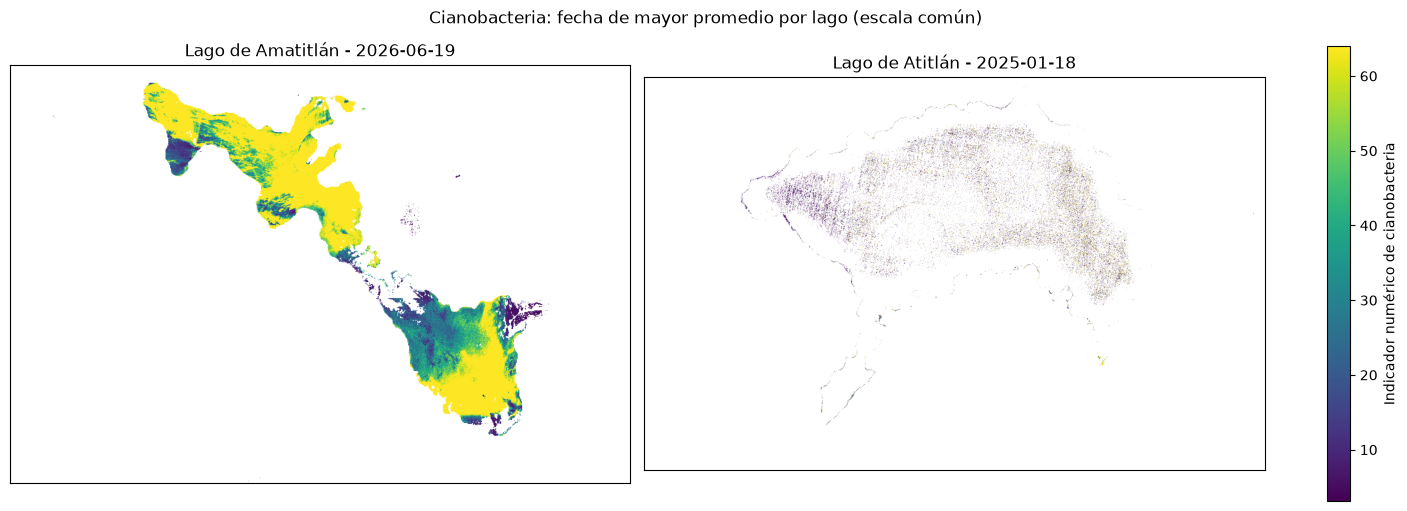

In [10]:
if metricas is not None:
    vmin = metricas['cianobacteria_promedio'].min()
    vmax = metricas['cianobacteria_promedio'].max()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    for ax, (lago, grupo) in zip(axes, metricas.groupby('lago')):
        escena = grupo.loc[grupo['cianobacteria_promedio'].idxmax()]
        _, capas = metrics_for_scene(lago, escena['fecha'])
        imagen = capas['cianobacteria'].copy()
        imagen[~capas['valid_mask']] = np.nan
        mapa = ax.imshow(imagen, cmap='viridis', vmin=vmin, vmax=vmax)
        ax.set(title=f"{LAKES[lago]['display_name']} - {escena['fecha']}", xticks=[], yticks=[])
    fig.colorbar(mapa, ax=axes, label='Indicador numérico de cianobacteria')
    fig.suptitle('Cianobacteria: fecha de mayor promedio por lago (escala común)')
    plt.show()
else:
    print('Mapa pendiente: aún no hay métricas verificables.')

## 4. Análisis temporal

Se usa como fecha crítica un **máximo local** cuyo promedio de cianobacteria es igual o superior al **percentil 75 de su propio lago**. El criterio se calcula por separado para no confundir las escalas y condiciones de Amatitlán y Atitlán.

,lago,fecha,pixeles_validos,cobertura_valida_pct,cianobacteria_promedio,umbral_percentil_75,es_pico,incidencia
0,amatitlan,2025-01-28,104762,8.400314,14.139632,19.857060,False,
1,amatitlan,2025-04-15,48363,3.877975,10.094927,19.857060,False,
2,amatitlan,2025-04-28,92362,7.406023,13.328804,19.857060,False,
3,amatitlan,2025-11-24,114263,9.162150,13.280656,19.857060,False,
4,amatitlan,2026-01-08,123144,9.874270,22.571541,19.857060,True,
5,amatitlan,2026-02-02,9620,0.771377,6.734544,19.857060,False,
6,amatitlan,2026-02-07,39998,3.207229,7.854832,19.857060,False,Cobertura válida parcial aproximada: 57.1%.
7,amatitlan,2026-03-29,89925,7.210613,17.142580,19.857060,False,
8,amatitlan,2026-04-13,137174,10.999262,16.553221,19.857060,False,
9,amatitlan,2026-04-28,131987,10.583344,24.164816,19.857060,False,


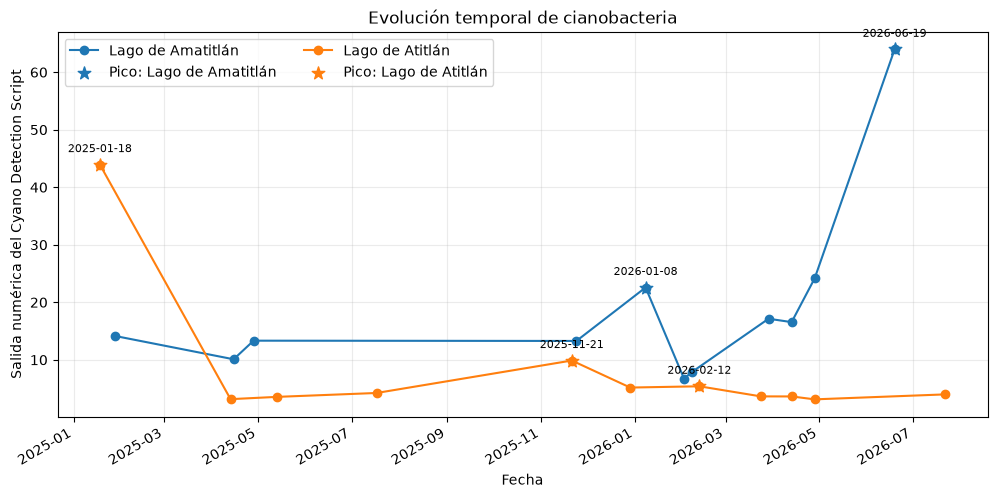

,lago,fecha_maxima,valor_maximo,numero_picos,interpretacion
0,amatitlan,2026-06-19,63.971619,2,La fecha máxima describe la señal del índice; ...
1,atitlan,2025-01-18,43.934631,3,La fecha máxima describe la señal del índice; ...


In [11]:
if metricas is not None:
    serie_temporal = detect_peaks(metricas)
    display(serie_temporal[['lago', 'fecha', 'pixeles_validos', 'cobertura_valida_pct', 'cianobacteria_promedio', 'umbral_percentil_75', 'es_pico', 'incidencia']])

    ax = plot_cyano_timeseries(serie_temporal)
    plt.show()

    resumen_temporal = temporal_interpretation(serie_temporal)
    display(resumen_temporal)
else:
    serie_temporal = None
    print('Análisis temporal pendiente: aún no hay métricas verificables.')

### Interpretación temporal inicial

La gráfica se lee de izquierda a derecha: cada punto es el promedio de píxeles válidos de una fecha oficial y las estrellas identifican fechas críticas. La tabla `resumen_temporal` reporta el máximo observado y el número de picos por lago. Esos son **hechos extraídos de los datos**. Lluvia, viento, temperatura, aportes de nutrientes y mezcla del agua son hipótesis que podrían explicar cambios, pero solo deben afirmarse tras contrastarlas con datos auxiliares; además, nubes, cobertura parcial o ausencia de máscara pueden alterar un promedio.

## 6. Correlaciones entre cianobacteria, NDVI y NDWI

La unidad de análisis es lago-fecha: cada fila resume los píxeles válidos de una escena. Con 11 fechas por lago, estas correlaciones son exploratorias y no demuestran causalidad.

,lago,relacion,predictor,n_fechas,pearson_r,pearson_p,spearman_rho,spearman_p,interpretacion
0,amatitlan,cianobacteria_vs_ndvi,ndvi_promedio,11,0.262732,0.435078,0.527273,0.095565,Relación positiva débil; no implica causalidad.
1,amatitlan,cianobacteria_vs_ndwi,ndwi_promedio,11,0.252956,0.452968,-0.181818,0.592615,Relación positiva débil; no implica causalidad.
2,atitlan,cianobacteria_vs_ndvi,ndvi_promedio,11,0.952126,0.000006,0.772727,0.005299,Relación positiva fuerte; no implica causalidad.
3,atitlan,cianobacteria_vs_ndwi,ndwi_promedio,11,0.723499,0.011848,0.936364,0.000022,Relación positiva fuerte; no implica causalidad.


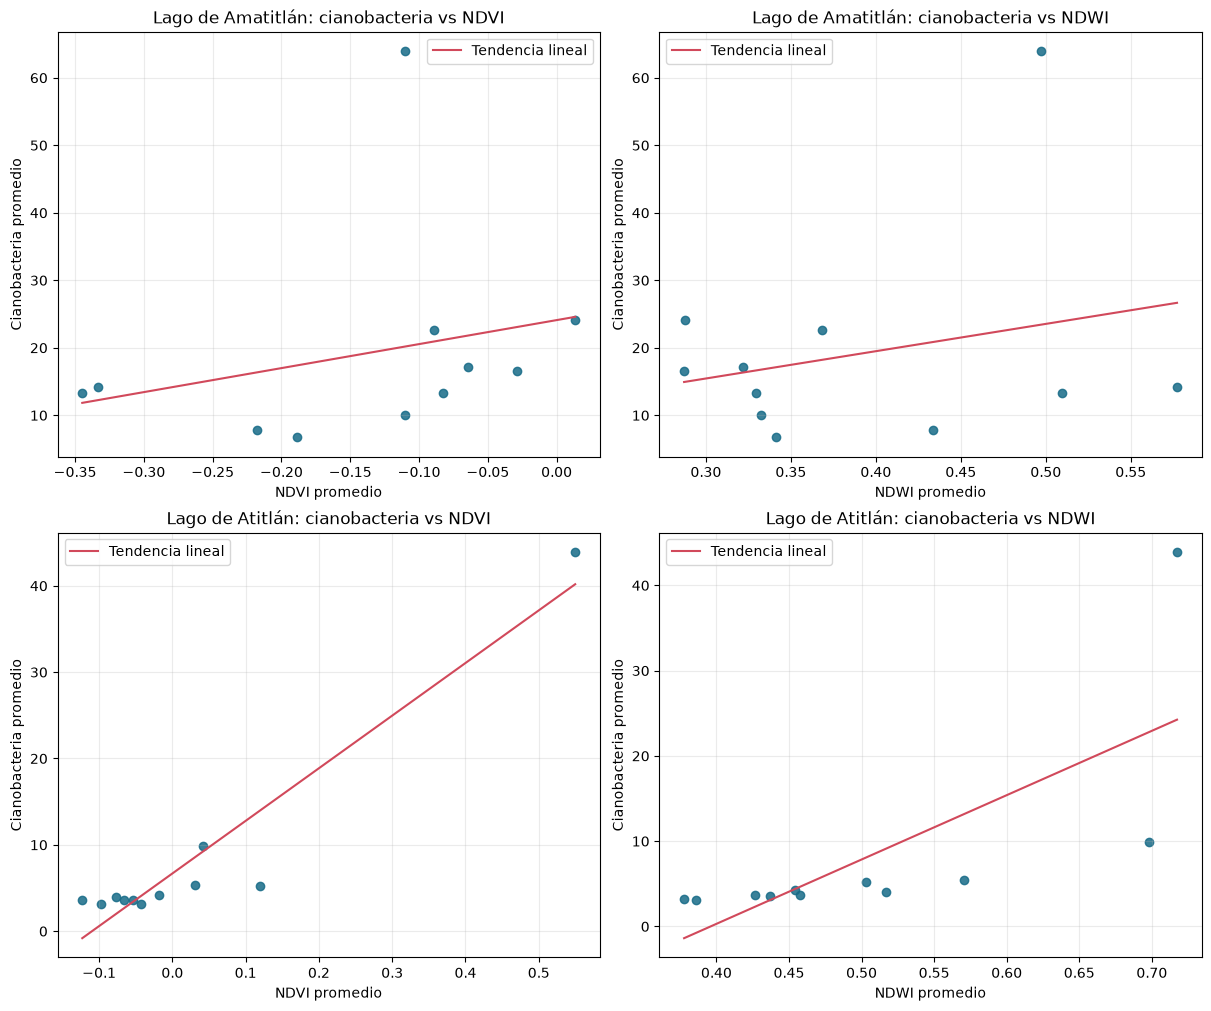

In [12]:
correlaciones = correlation_table(metricas)
display(correlaciones)
fig_correlaciones = plot_correlations(metricas)
Path('outputs/figuras').mkdir(parents=True, exist_ok=True)
fig_correlaciones.savefig('outputs/figuras/correlaciones_por_lago.png', dpi=180, bbox_inches='tight')
plt.show()

## Metodología y limitaciones del avance

Se usan imágenes Sentinel-2 en las 11 fechas oficiales por lago. B04 y B08 permiten calcular NDVI; B03 y B08, NDWI. La estimación de cianobacteria se deriva del producto numérico documentado del algoritmo CyanoLakes, no de una interpretación visual de colores. Las métricas se calculan únicamente sobre píxeles válidos y la misma regla de máscara se aplica a todas las fechas.

El archivo `outputs/tablas/inventario_datos.csv` conserva la trazabilidad de cada imagen y `outputs/tablas/lista_control_calidad_avance.csv` registra si los insumos necesarios están disponibles. La ausencia de una máscara vectorial precisa, nubes, cobertura parcial y la naturaleza indirecta de la estimación limitan las conclusiones.

## Conclusiones del avance

El avance deja una cadena reproducible para validar las fechas, descargar las bandas mínimas, calcular índices y detectar picos con un criterio explícito. Las conclusiones ambientales se incorporarán únicamente después de que las figuras y la tabla de métricas se generen con los 22 pares de insumos validados.

## 5. Análisis espacial - pendiente de fase 2

Se incorporarán mapas comparativos, extensión de valores altos y persistencia espacial.

## 6.1. Integración con la fase final

Se evaluarán las relaciones entre cianobacteria, NDVI y NDWI.

## 7. Comparación de lagos - pendiente de fase 2

Se compararán intensidad, frecuencia y causas potenciales con evidencia de tablas y figuras.

## 8. Análisis exploratorio adicional - pendiente de fase 2

Se analizarán área alta, persistencia, distribuciones y estacionalidad.